In [1]:
!pip install -q onnx onnxruntime onnxscript
!pip install -q pytorch-msssim
import os, glob, random, json, math
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2
from pytorch_msssim import ssim
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_fscore_support, roc_auc_score,
                             confusion_matrix, mean_absolute_error, mean_squared_error)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ROOT = "/content/data"
os.makedirs(ROOT, exist_ok=True)

Using device: cuda


In [2]:

import requests, random
from concurrent.futures import ThreadPoolExecutor

!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/ann.zip
!unzip -q /content/ann.zip "annotations/captions_train2017.json" -d /content/ann

import json
with open("/content/ann/annotations/captions_train2017.json") as f:
    coco_meta = json.load(f)
image_infos = coco_meta["images"]

N_IMAGES = 6000
random.seed(SEED)
sampled = random.sample(image_infos, N_IMAGES)

os.makedirs("/content/coco_train", exist_ok=True)

def download_one(info):
    out_path = os.path.join("/content/coco_train", info["file_name"])
    if os.path.exists(out_path):
        return
    try:
        r = requests.get(info["coco_url"], timeout=10)
        if r.status_code == 200:
            with open(out_path, "wb") as f:
                f.write(r.content)
    except Exception:
        pass

with ThreadPoolExecutor(max_workers=32) as ex:
    list(tqdm(ex.map(download_one, sampled), total=len(sampled)))

all_paths = sorted(glob.glob("/content/coco_train/*.jpg"))
print("Downloaded:", len(all_paths))

replace /content/ann/annotations/captions_train2017.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


100%|██████████| 6000/6000 [00:00<00:00, 50007.00it/s]

Downloaded: 10000


In [3]:
random.shuffle(all_paths)
clean_paths = all_paths[:min(N_IMAGES, len(all_paths))]

train_paths, temp_paths = train_test_split(clean_paths, test_size=0.30, random_state=SEED)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.50, random_state=SEED)

print(f"train={len(train_paths)} val={len(val_paths)} test={len(test_paths)}")

train=4200 val=900 test=900


In [4]:
def compute_classical_features(img_bgr):
    """img_bgr: HxWx3 uint8 BGR image. Returns a 16-dim np.float32 vector."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
    brightness = gray.mean()
    contrast = gray.std()

    median = cv2.medianBlur(gray, 3)
    noise_estimate = np.mean(np.abs(gray.astype(np.float32) - median.astype(np.float32)))

    saturation = hsv[:, :, 1].mean()

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.mean(edges > 0)

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-8)
    entropy = -np.sum(hist * np.log2(hist + 1e-8))

    b, g, r = cv2.split(img_bgr.astype(np.float32))
    rg = r - g
    yb = 0.5 * (r + g) - b
    colorfulness = np.sqrt(rg.std()**2 + yb.std()**2) + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2)

    pct_shadow_clip_15 = np.mean(gray < 15)
    pct_shadow_clip_30 = np.mean(gray < 30)
    pct_highlight_clip_240 = np.mean(gray > 240)
    pct_highlight_clip_225 = np.mean(gray > 225)

    p01 = np.percentile(gray, 1)
    p05 = np.percentile(gray, 5)
    p95 = np.percentile(gray, 95)
    p99 = np.percentile(gray, 99)

    feats = np.array([sharpness, brightness, contrast, noise_estimate,
                       saturation, edge_density, entropy, colorfulness,
                       pct_shadow_clip_15, pct_shadow_clip_30,
                       pct_highlight_clip_240, pct_highlight_clip_225,
                       p01, p05, p95, p99], dtype=np.float32)
    return feats

def resize_with_padding(img, target_size):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (new_w, new_h))
    pad_h, pad_w = target_size - new_h, target_size - new_w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    return cv2.copyMakeBorder(resized, top, bottom, left, right,
                               cv2.BORDER_CONSTANT, value=[0, 0, 0])

CLASSICAL_FEAT_NAMES = ["sharpness", "brightness", "contrast",
                         "noise_estimate", "saturation", "edge_density",
                         "entropy", "colorfulness", "pct_shadow_clip_15",
                         "pct_shadow_clip_30", "pct_highlight_clip_240",
                         "pct_highlight_clip_225", "p01", "p05", "p95", "p99"]

In [5]:
def apply_blur(img, sigma):
    k = max(3, int(sigma * 6) | 1)
    return cv2.GaussianBlur(img, (k, k), sigma)

def apply_exposure(img, gamma):
    table = ((np.arange(256) / 255.0) ** gamma * 255).astype(np.uint8)
    return cv2.LUT(img, table)

def apply_noise(img, sigma):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype("uint8")

def apply_corruption(img, quality):
    ok, enc = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, quality])
    return cv2.imdecode(enc, cv2.IMREAD_COLOR)

def apply_structural_artifact(img, coverage_frac, sub_type=None):
    out = img.copy()
    h, w = out.shape[:2]
    area_target = coverage_frac * h * w
    side = max(20, min(int(np.sqrt(area_target)), min(h, w)))

    if sub_type is None:
        sub_type = random.choice([
            "checkerboard", "channel_shift", "block_fill",
            "local_noise", "scratch_bundle", "dead_pixel_cluster", "streak_lines"
        ])

    if sub_type == "checkerboard":
        x, y = random.randint(0, w - side), random.randint(0, h - side)
        tile = max(4, side // 12)
        patch = out[y:y+side, x:x+side].copy()
        for i in range(0, side, tile):
            for j in range(0, side, tile):
                patch[i:i+tile, j:j+tile] = 255 if (i//tile + j//tile) % 2 == 0 else 0
        out[y:y+side, x:x+side] = patch

    elif sub_type == "channel_shift":
        band_h = max(20, int(coverage_frac * h))
        y = random.randint(0, h - band_h)
        channel = random.randint(0, 2)
        amount = random.randint(60, 140)
        out[y:y+band_h, :, channel] = np.clip(
            out[y:y+band_h, :, channel].astype(np.int16) + amount, 0, 255).astype(np.uint8)

    elif sub_type == "block_fill":
        x, y = random.randint(0, w - side), random.randint(0, h - side)
        color = tuple(int(c) for c in np.random.randint(0, 255, 3))
        cv2.rectangle(out, (x, y), (x+side, y+side), color, -1)

    elif sub_type == "local_noise":
        x, y = random.randint(0, w - side), random.randint(0, h - side)
        patch = out[y:y+side, x:x+side]
        noise = np.random.normal(0, random.uniform(40, 90), patch.shape)
        out[y:y+side, x:x+side] = np.clip(patch.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    elif sub_type == "scratch_bundle":
        for _ in range(max(2, int(coverage_frac * 10))):
            x1, y1 = random.randint(0, w-1), random.randint(0, h-1)
            length = random.randint(int(min(h,w)*0.2), int(min(h,w)*0.6))
            angle = random.uniform(0, 2*np.pi)
            x2 = int(np.clip(x1 + length*np.cos(angle), 0, w-1))
            y2 = int(np.clip(y1 + length*np.sin(angle), 0, h-1))
            val = random.choice([random.randint(200,255), random.randint(0,50)])
            cv2.line(out, (x1,y1), (x2,y2), (val,val,val), thickness=random.randint(3,7))

    elif sub_type == "dead_pixel_cluster":
        for _ in range(max(20, int(200 * coverage_frac))):
            x, y = random.randint(0, w-1), random.randint(0, h-1)
            color = random.choice([(0,0,0),(255,255,255),
                                    tuple(int(v) for v in np.random.randint(0,256,3))])
            cv2.circle(out, (x,y), random.randint(1,3), color, -1)

    elif sub_type == "streak_lines":
        for _ in range(max(2, int(coverage_frac * 12))):
            y = random.randint(0, h-1)
            color = tuple(int(c) for c in np.random.randint(0,255,3))
            cv2.line(out, (0,y), (w,y), color, random.randint(2,5))

    return out

ISSUE_NAMES = ["blur", "underexposure", "overexposure", "noise", "corruption", "structural_artifact"]
ISSUE_PENALTY = {"blur": 25, "underexposure": 20, "overexposure": 20,
                  "noise": 20, "corruption": 20, "structural_artifact": 30}

def generate_variant(img_bgr):
    label = np.zeros(len(ISSUE_NAMES), dtype=np.float32)
    severities = {}
    out = img_bgr.copy()

    if random.random() < 0.10:
        return out, label, severities, 100.0

    k = random.choices([1, 2, 3], weights=[0.30, 0.40, 0.30])[0]
    possible = random.sample(ISSUE_NAMES, k=k)

    # underexposure and overexposure cancel each other out visually — never co-sample
    if "underexposure" in possible and "overexposure" in possible:
        possible.remove(random.choice(["underexposure", "overexposure"]))

    if "structural_artifact" not in possible and random.random() < 0.35:
        possible.append("structural_artifact")

    for issue in possible:
        if issue == "blur":
            sigma = random.uniform(2.0, 8.0)
            out = apply_blur(out, sigma)
            sev = min(sigma / 8.0, 1.0)
        elif issue == "underexposure":
            gamma = random.uniform(2.2, 4.5)
            out = apply_exposure(out, gamma)
            sev = (gamma - 2.2) / (4.5 - 2.2)
        elif issue == "overexposure":
            gamma = random.uniform(0.1, 0.45)
            out = apply_exposure(out, gamma)
            sev = (0.45 - gamma) / (0.45 - 0.1)
        elif issue == "noise":
            sigma = random.uniform(20, 70)
            out = apply_noise(out, sigma)
            sev = min(sigma / 70.0, 1.0)
        elif issue == "corruption":
            quality = random.randint(3, 20)
            out = apply_corruption(out, quality)
            sev = min((20 - quality) / 17.0, 1.0)
        elif issue == "structural_artifact":
            coverage = random.uniform(0.15, 1.0)
            out = apply_structural_artifact(out, coverage)
            sev = coverage

        idx = ISSUE_NAMES.index(issue)
        label[idx] = 1.0
        severities[issue] = float(sev)

    penalty = sum(severities[i] * ISSUE_PENALTY[i] for i in severities)
    score = float(np.clip(100.0 - penalty, 0, 100))
    return out, label, severities, score

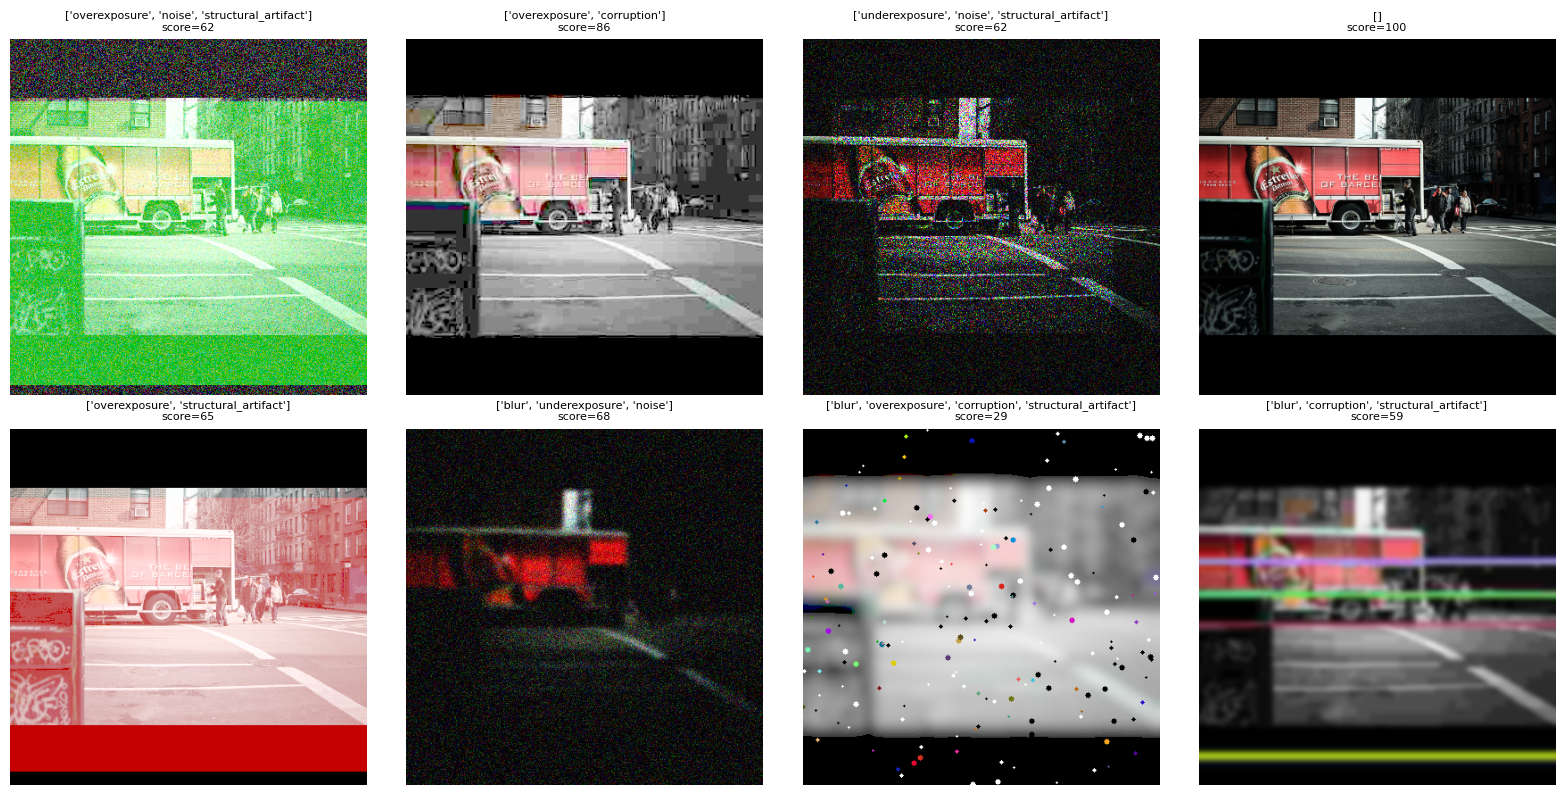

In [6]:
import matplotlib.pyplot as plt
sample_img = cv2.imread(train_paths[0])
sample_img = resize_with_padding(sample_img, 400)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.flat:
    deg, label, sev, score = generate_variant(sample_img)
    ax.imshow(cv2.cvtColor(deg, cv2.COLOR_BGR2RGB))
    issues = [ISSUE_NAMES[i] for i in range(len(label)) if label[i]==1]
    ax.set_title(f"{issues}\nscore={score:.0f}", fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
def build_split(paths, split_name, variants_per_image=3, img_size=400):
    out_dir = os.path.join(ROOT, split_name)
    os.makedirs(out_dir, exist_ok=True)

    rows = []
    counter = 0
    for p in tqdm(paths, desc=f"Building {split_name}"):
        img = cv2.imread(p)
        if img is None:
            continue
        img = resize_with_padding(img, img_size)
        for v in range(variants_per_image):
            deg_img, label, sev, score = generate_variant(img)
            fname = f"{split_name}_{counter:06d}.jpg"
            fpath = os.path.join(out_dir, fname)
            cv2.imwrite(fpath, deg_img)
            row = {"path": fpath, "quality_score": score}
            for i, name in enumerate(ISSUE_NAMES):
                row[name] = label[i]
            rows.append(row)
            counter += 1
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(ROOT, f"{split_name}_labels.csv"), index=False)
    return df

train_df = build_split(train_paths, "train", variants_per_image=4)
val_df   = build_split(val_paths,   "val",   variants_per_image=2)
test_df  = build_split(test_paths,  "test",  variants_per_image=2)

print(train_df.shape, val_df.shape, test_df.shape)

Building train:  51%|█████     | 2145/4200 [01:46<01:17, 26.53it/s]

In [ ]:
AE_SIZE = 256

ae_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((AE_SIZE, AE_SIZE)),
    transforms.ToTensor(),
])

class CleanImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return ae_transform(img)

clean_train_ds = CleanImageDataset(train_paths)
clean_val_ds   = CleanImageDataset(val_paths)
clean_train_loader = DataLoader(clean_train_ds, batch_size=32, shuffle=True, num_workers=2)
clean_val_loader   = DataLoader(clean_val_ds, batch_size=32, shuffle=False, num_workers=2)

def gradient_loss(recon, target):
    recon_dx = recon[:, :, :, 1:] - recon[:, :, :, :-1]
    recon_dy = recon[:, :, 1:, :] - recon[:, :, :-1, :]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    loss_x = F.l1_loss(recon_dx, target_dx)
    loss_y = F.l1_loss(recon_dy, target_dy)
    return loss_x + loss_y

def ae_loss(recon, target):
    mse = F.mse_loss(recon, target)
    ssim_loss = 1 - ssim(recon, target, data_range=1.0, size_average=True)
    grad = gradient_loss(recon, target)
    return 0.55 * mse + 0.30 * ssim_loss + 0.15 * grad

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)

In [ ]:
autoencoder = ConvAutoencoder().to(device)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

AE_EPOCHS = 15
best_val_loss = float("inf")

for epoch in range(AE_EPOCHS):
    autoencoder.train()
    train_loss = 0.0
    for clean_img in clean_train_loader:
        clean_img = clean_img.to(device)
        recon = autoencoder(clean_img)
        loss = ae_loss(recon, clean_img)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        train_loss += loss.item() * clean_img.size(0)
    train_loss /= len(clean_train_ds)

    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for clean_img in clean_val_loader:
            clean_img = clean_img.to(device)
            recon = autoencoder(clean_img)
            val_loss += ae_loss(recon, clean_img).item() * clean_img.size(0)
    val_loss /= len(clean_val_ds)

    print(f"[AE] epoch {epoch+1}/{AE_EPOCHS} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(autoencoder.state_dict(), os.path.join(ROOT, "autoencoder.pt"))

autoencoder.load_state_dict(torch.load(os.path.join(ROOT, "autoencoder.pt")))
autoencoder.eval()
for p in autoencoder.parameters():
    p.requires_grad = False
print("Autoencoder frozen and ready.")

In [ ]:
@torch.no_grad()
def extract_anomaly_feats(model, img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor = ae_transform(img_rgb).unsqueeze(0).to(device)
    recon = model(tensor)
    err_map = (tensor - recon).pow(2).mean(dim=1).squeeze(0).cpu().numpy()

    h, w = err_map.shape
    grid_errors = []
    for gy in range(8):
        for gx in range(8):
            y1, y2 = gy * h // 8, (gy + 1) * h // 8
            x1, x2 = gx * w // 8, (gx + 1) * w // 8
            grid_errors.append(err_map[y1:y2, x1:x2].mean())
    grid_errors = np.array(grid_errors)
    local_max_err = grid_errors.max()
    local_std_err = grid_errors.std()

    mean_err = err_map.mean()
    max_err = err_map.max()
    std_err = err_map.std()
    p90 = np.percentile(err_map, 90)
    p99 = np.percentile(err_map, 99)
    pct_anomalous = np.mean(err_map > (mean_err + 2 * std_err))

    gray_input = (0.299*tensor[:,0] + 0.587*tensor[:,1] + 0.114*tensor[:,2]).unsqueeze(1)
    gray_recon = (0.299*recon[:,0] + 0.587*recon[:,1] + 0.114*recon[:,2]).unsqueeze(1)

    input_dx = gray_input[:, :, :, 1:] - gray_input[:, :, :, :-1]
    input_dy = gray_input[:, :, 1:, :] - gray_input[:, :, :-1, :]
    recon_dx = gray_recon[:, :, :, 1:] - gray_recon[:, :, :, :-1]
    recon_dy = gray_recon[:, :, 1:, :] - gray_recon[:, :, :-1, :]

    grad_error_x = torch.abs(input_dx - recon_dx)
    grad_error_y = torch.abs(input_dy - recon_dy)
    grad_error = torch.cat([grad_error_x.flatten(), grad_error_y.flatten()])

    mean_grad_err = grad_error.mean().item()
    max_grad_err = grad_error.max().item()
    p95_grad_err = torch.quantile(grad_error, 0.95).item()

    return np.array([
        mean_err, max_err, std_err, p90, p99, pct_anomalous,
        mean_grad_err, max_grad_err, p95_grad_err, local_max_err, local_std_err
    ], dtype=np.float32), err_map

ANOMALY_FEAT_NAMES = ["mean_err", "max_err", "std_err", "p90_err", "p99_err",
                       "pct_anomalous", "mean_grad_err", "max_grad_err",
                       "p95_grad_err", "local_max_err", "local_std_err"]

In [ ]:
def precompute_features(df, split_name):
    classical_list, anomaly_list = [], []
    for p in tqdm(df["path"], desc=f"Features {split_name}"):
        img = cv2.imread(p)
        classical_list.append(compute_classical_features(img))
        a_feats, _ = extract_anomaly_feats(autoencoder, img)
        anomaly_list.append(a_feats)

    classical_arr = np.stack(classical_list)
    anomaly_arr = np.stack(anomaly_list)

    np.save(os.path.join(ROOT, f"{split_name}_classical.npy"), classical_arr)
    np.save(os.path.join(ROOT, f"{split_name}_anomaly.npy"), anomaly_arr)
    return classical_arr, anomaly_arr

train_classical, train_anomaly = precompute_features(train_df, "train")
val_classical,   val_anomaly   = precompute_features(val_df, "val")
test_classical,  test_anomaly  = precompute_features(test_df, "test")

classical_mean, classical_std = train_classical.mean(0), train_classical.std(0) + 1e-8
anomaly_mean, anomaly_std     = train_anomaly.mean(0), train_anomaly.std(0) + 1e-8

def normalize(arr, mean, std):
    return (arr - mean) / std

train_classical_n = normalize(train_classical, classical_mean, classical_std)
val_classical_n   = normalize(val_classical, classical_mean, classical_std)
test_classical_n  = normalize(test_classical, classical_mean, classical_std)

train_anomaly_n = normalize(train_anomaly, anomaly_mean, anomaly_std)
val_anomaly_n   = normalize(val_anomaly, anomaly_mean, anomaly_std)
test_anomaly_n  = normalize(test_anomaly, anomaly_mean, anomaly_std)

np.savez(os.path.join(ROOT, "norm_stats.npz"),
         classical_mean=classical_mean, classical_std=classical_std,
         anomaly_mean=anomaly_mean, anomaly_std=anomaly_std)

In [ ]:
IMG_SIZE = 224

cnn_transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cnn_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FusionDataset(Dataset):
    def __init__(self, df, classical_n, anomaly_n, transform):
        self.df = df.reset_index(drop=True)
        self.classical_n = classical_n
        self.anomaly_n = anomaly_n
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_t = self.transform(img)
        classical_t = torch.tensor(self.classical_n[idx], dtype=torch.float32)
        anomaly_t = torch.tensor(self.anomaly_n[idx], dtype=torch.float32)
        issue_labels = torch.tensor(row[ISSUE_NAMES].values.astype(np.float32))
        score = torch.tensor([row["quality_score"] / 100.0], dtype=torch.float32)
        return img_t, classical_t, anomaly_t, issue_labels, score

train_fusion_ds = FusionDataset(train_df, train_classical_n, train_anomaly_n, cnn_transform_train)
val_fusion_ds   = FusionDataset(val_df, val_classical_n, val_anomaly_n, cnn_transform)
test_fusion_ds  = FusionDataset(test_df, test_classical_n, test_anomaly_n, cnn_transform)

train_fusion_loader = DataLoader(train_fusion_ds, batch_size=32, shuffle=True, num_workers=2)
val_fusion_loader   = DataLoader(val_fusion_ds, batch_size=32, shuffle=False, num_workers=2)
test_fusion_loader  = DataLoader(test_fusion_ds, batch_size=32, shuffle=False, num_workers=2)

class FusedQualityModel(nn.Module):
    def __init__(self, n_issues=6, n_engineered=16, n_anomaly_feats=11):
        super().__init__()
        backbone = mobilenet_v2(weights="IMAGENET1K_V2")
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.cnn_norm = nn.LayerNorm(1280)
        fusion_dim = 1280 + n_engineered + n_anomaly_feats
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU()
        )
        self.issue_out = nn.Linear(64, n_issues)
        self.defect_out = nn.Linear(64, 1)
        self.score_out = nn.Linear(64, 1)
        self.classical_direct = nn.Linear(n_engineered, n_issues, bias=True)
        self.classical_direct_scale = 0.5

    def forward(self, img, engineered_feats, anomaly_feats):
        cnn_emb = self.cnn_norm(self.pool(self.features(img)).flatten(1))
        x = torch.cat([cnn_emb, engineered_feats, anomaly_feats], dim=1)
        x = self.head(x)
        issue_logits = (self.issue_out(x) +
                         self.classical_direct_scale * self.classical_direct(engineered_feats))
        score = torch.sigmoid(self.score_out(x))
        return issue_logits, self.defect_out(x), score

In [ ]:
def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for img, classical, anomaly, issue_labels, score in loader:
            img, classical, anomaly = img.to(device), classical.to(device), anomaly.to(device)
            issue_labels, score = issue_labels.to(device), score.to(device)

            issue_logits, defect_logit, score_pred = model(img, classical, anomaly)
            defect_label = (issue_labels.sum(dim=1) > 0).float().unsqueeze(1)

            loss_issue = bce_loss(issue_logits, issue_labels)
            loss_defect = F.binary_cross_entropy_with_logits(defect_logit, defect_label)
            loss_score = mse_loss(score_pred, score)
            loss = 1.0 * loss_issue + 0.3 * loss_defect + 1.2 * loss_score

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * img.size(0)
    return total_loss / len(loader.dataset)

In [ ]:
model = FusedQualityModel(n_issues=len(ISSUE_NAMES), n_engineered=16, n_anomaly_feats=11).to(device)

pos_weight = torch.tensor([1.0, 1.3, 1.3, 1.0, 1.0, 1.2], device=device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mse_loss = nn.MSELoss()

# Phase 2a — freeze CNN backbone, train the head
for p in model.features.parameters():
    p.requires_grad = False

optimizer_a = torch.optim.Adam(
    list(model.head.parameters()) + list(model.issue_out.parameters()) +
    list(model.defect_out.parameters()) + list(model.score_out.parameters()) +
    list(model.classical_direct.parameters()),
    lr=1e-3, weight_decay=1e-4
)

WARMUP_EPOCHS = 4
for epoch in range(WARMUP_EPOCHS):
    tr_loss = run_epoch(train_fusion_loader, model, optimizer_a)
    val_loss = run_epoch(val_fusion_loader, model)
    print(f"[Phase2a] epoch {epoch+1}/{WARMUP_EPOCHS} train_loss={tr_loss:.4f} val_loss={val_loss:.4f}")

# Phase 2b — unfreeze last few backbone blocks, fine-tune at low LR
for p in model.features[-4:].parameters():
    p.requires_grad = True

optimizer_b = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, mode="min", factor=0.5, patience=2, min_lr=1e-7)

FINETUNE_EPOCHS = 10
best_val_loss = float("inf")
wait = 0
patience = 6

for epoch in range(FINETUNE_EPOCHS):
    tr_loss = run_epoch(train_fusion_loader, model, optimizer_b)
    val_loss = run_epoch(val_fusion_loader, model)
    scheduler_b.step(val_loss)
    print(f"[Phase2b] epoch {epoch+1}/{FINETUNE_EPOCHS} train_loss={tr_loss:.4f} val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(ROOT, "fusion_model.pt"))
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping")
            break

model.load_state_dict(torch.load(os.path.join(ROOT, "fusion_model.pt")))
model.eval()
print("Fusion model trained and saved.")

In [ ]:
@torch.no_grad()
def collect_predictions(loader, model):
    all_issue_probs, all_issue_true = [], []
    all_score_pred, all_score_true = [], []
    for img, classical, anomaly, issue_labels, score in loader:
        img, classical, anomaly = img.to(device), classical.to(device), anomaly.to(device)
        issue_logits, defect_logit, score_pred = model(img, classical, anomaly)
        all_issue_probs.append(torch.sigmoid(issue_logits).cpu().numpy())
        all_issue_true.append(issue_labels.numpy())
        all_score_pred.append(score_pred.cpu().numpy())
        all_score_true.append(score.numpy())
    return (np.concatenate(all_issue_probs), np.concatenate(all_issue_true),
            np.concatenate(all_score_pred), np.concatenate(all_score_true))

issue_probs, issue_true, score_pred, score_true = collect_predictions(test_fusion_loader, model)
issue_pred_bin = (issue_probs > 0.5).astype(int)

print("\n=== Per-issue metrics (test set) ===")
for i, name in enumerate(ISSUE_NAMES):
    p, r, f1, _ = precision_recall_fscore_support(
        issue_true[:, i], issue_pred_bin[:, i], average="binary", zero_division=0)
    try:
        auc = roc_auc_score(issue_true[:, i], issue_probs[:, i])
    except ValueError:
        auc = float("nan")
    cm = confusion_matrix(issue_true[:, i], issue_pred_bin[:, i])
    print(f"{name:20s} precision={p:.3f} recall={r:.3f} f1={f1:.3f} auc={auc:.3f}")
    print(f"  confusion_matrix:\n{cm}")

score_pred_clipped = np.clip(score_pred, 0, 1)
mae = mean_absolute_error(score_true * 100, score_pred_clipped * 100)
rmse = math.sqrt(mean_squared_error(score_true * 100, score_pred_clipped * 100))
print(f"\nQuality score regression — MAE={mae:.2f} RMSE={rmse:.2f}")

In [ ]:
model.eval()
dummy_img = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_classical = torch.randn(1, 16).to(device)
dummy_anomaly = torch.randn(1, 11).to(device)

torch.onnx.export(
    model, (dummy_img, dummy_classical, dummy_anomaly),
    os.path.join(ROOT, "fusion_model.onnx"),
    input_names=["image", "classical_feats", "anomaly_feats"],
    output_names=["issue_logits", "defect_logit", "score_pred"],
    dynamic_axes={"image": {0: "batch"}, "classical_feats": {0: "batch"},
                  "anomaly_feats": {0: "batch"}},
    opset_version=18
)

autoencoder.eval()
dummy_ae_input = torch.randn(1, 3, AE_SIZE, AE_SIZE).to(device)
torch.onnx.export(
    autoencoder, dummy_ae_input,
    os.path.join(ROOT, "autoencoder.onnx"),
    input_names=["image"], output_names=["reconstruction"],
    dynamic_axes={"image": {0: "batch"}, "reconstruction": {0: "batch"}},
    opset_version=18
)

print("Exported: fusion_model.onnx, autoencoder.onnx")

In [ ]:
feature_config = {
    "issue_names": ISSUE_NAMES,
    "classical_feat_names": CLASSICAL_FEAT_NAMES,
    "anomaly_feat_names": ANOMALY_FEAT_NAMES,
    "quality_label_thresholds": {"ACCEPTABLE": 80, "DEGRADED": 50},
    "issue_threshold": 0.5,
    "img_size_pad": 400,
    "ae_size": 256,
    "cnn_size": 224
}
with open(os.path.join(ROOT, "feature_config.json"), "w") as f:
    json.dump(feature_config, f, indent=2)

print("Saved feature_config.json")

In [ ]:
import onnxruntime as ort

sess_fusion = ort.InferenceSession(os.path.join(ROOT, "fusion_model.onnx"))
sess_ae = ort.InferenceSession(os.path.join(ROOT, "autoencoder.onnx"))

img_t, classical_t, anomaly_t, _, _ = test_fusion_ds[0]
img_np = img_t.unsqueeze(0).numpy()
classical_np = classical_t.unsqueeze(0).numpy()
anomaly_np = anomaly_t.unsqueeze(0).numpy()

onnx_out = sess_fusion.run(None, {"image": img_np, "classical_feats": classical_np, "anomaly_feats": anomaly_np})

with torch.no_grad():
    torch_out = model(img_t.unsqueeze(0).to(device), classical_t.unsqueeze(0).to(device), anomaly_t.unsqueeze(0).to(device))

print("ONNX score_pred:", onnx_out[2])
print("Torch score_pred:", torch_out[2].cpu().numpy())
print("Max diff:", np.max(np.abs(onnx_out[2] - torch_out[2].cpu().numpy())))